Deep Q-Network Learning

In [2]:
import torch
import numpy as np
import time, random
import torch.nn as nn
import gymnasium as gym
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
@dataclass
class Config:
    env_id: str = "CartPole-v1"
    total_steps: int = 60_000
    buffer_size: int = 50_000
    batch_size: int = 64
    gamma: float = 0.99
    lr: float = 1e-3
    hidden: int = 128
    learning_starts: int = 1_000 # warmup for buffer init
    train_every: int = 1 # env steps per gradient step
    target_sync_every: int = 500 # gradient steps per hard target copy
    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay_steps: int = 10_000    # linear decay
    eval_window: int = 100
    solve_threshold: float = 475.0   # CartPole-v1: mean return >= 475 over 100 episodes

CFG = Config()
Q_CEILING = (1 - CFG.gamma ** 500)/(1 - CFG.gamma)

In [5]:
Q_CEILING

99.34295169575846

Replay Buffer

In [6]:
class ReplayBuffer:
    """FIFO ring buffer over np arrays. Stores only terminated episodes"""
    def __init__(self, capacity: int, obs_dim: int):
        self.capacity = capacity
        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.terminated = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0

    def add(self, state, action, reward, next_state, terminated):
        i = self.pos
        self.states[i] = state
        self.actions[i] = action
        self.rewards[i] = reward
        self.next_states[i] = next_state
        self.terminated[i] = terminated
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        pick = lambda arr, dtype: torch.as_tensor(arr[idx], dtype=dtype, device=device)
        return (
            pick(self.states, torch.float32),
            pick(self.actions, torch.int64),
            pick(self.rewards, torch.float32),
            pick(self.next_states, torch.float32),
            pick(self.terminated, torch.float32),
        )

    def __len__(self):
        return self.size

Q-Network and Epsilon Schedule

In [7]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, n_hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)

Epsilon Decay

In [8]:
def epsilon_at(step: int, cfg: Config) -> float:
    frac = min(step / cfg.eps_decay_steps, 1.0)
    return cfg.eps_start + frac * (cfg.eps_end - cfg.eps_start)

Training Loop

In [30]:
def train(seed: int, config: Config, log_every: int = 500):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(config.env_id)
    env.action_space.seed(seed=seed)
    obs, _ = env.reset(seed=seed)

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_net = QNetwork(obs_dim, n_actions, config.hidden).to(device)
    target_net = QNetwork(obs_dim, n_actions, config.hidden).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = torch.optim.Adam(q_net.parameters(), lr=config.lr)
    buffer = ReplayBuffer(config.buffer_size, obs_dim)

    keys = ("step", "return", "epsilon", "mean_q", "td_error", "buffer_size", "updates_per_step", "infer_ms")
    history = {k: [] for k in keys}
    returns, ep_return, grad_steps, solved_at = [], 0.0, 0, None
    recent_q, recent_td, latencies = [], [], []

    for step in range(1, config.total_steps + 1):
        eps = epsilon_at(step, config)

        # Explore vs Exploit
        if random.random() < eps:
            action = int(env.action_space.sample())
        else:
            t0 = time.perf_counter()
            with torch.no_grad():
                state_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
                q_values = q_net(state_t.unsqueeze(0))
            latencies.append((time.perf_counter() - t0) * 1e3)
            action = int(q_values.argmax(dim=1).item())

        next_obs, reward, terminated, truncated, _ = env.step(action)
        ep_return += reward

        buffer.add(obs, action, reward, next_obs, terminated)
        obs = next_obs

        if terminated or truncated:
            returns.append(ep_return)
            ep_return = 0.0
            obs, _ = env.reset()

        if len(buffer) >= config.learning_starts and step % config.train_every == 0:
            states, actions, rewards, next_states, dones = buffer.sample(config.batch_size)

            with torch.no_grad():
                next_q = target_net(next_states).max(dim=1).values
                targets = rewards + config.gamma * (1.0 - dones) * next_q

            pred = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            loss = F.smooth_l1_loss(pred, targets)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm(q_net.parameters(), 10.0)
            optimizer.step()
            grad_steps += 1

            recent_q.append(pred.mean().item())
            recent_td.append((targets - pred).abs().mean().item())

            if grad_steps % config.target_sync_every == 0:
                target_net.load_state_dict(q_net.state_dict())

        if solved_at is None and len(returns) >= config.eval_window and np.mean(returns[-config.eval_window:]) >= config.solve_threshold:
            solved_at = step

        if step % log_every == 0:
            window = returns[-config.eval_window:]
            history["step"].append(step)
            history["return"].append(float(np.mean(window)) if window else 0.0)
            history["epsilon"].append(eps)
            history["mean_q"].append(float(np.mean(recent_q)) if recent_q else 0.0)
            history["td_error"].append(float(np.mean(recent_td)) if recent_td else 0.0)
            history["buffer_size"].append(len(buffer))
            history["updates_per_step"].append(grad_steps / step)
            history["infer_ms"].append(float(np.mean(latencies[-1000:])) if latencies else 0.0)
            recent_q.clear()
            recent_td.clear()
    env.close()
    return {
        "seed": seed,
        "history": history,
        "returns": returns,
        "solved_at": solved_at,
        "q_net": q_net
    }

In [33]:
SEEDS = [0, 1, 2]
results = []

for seed in SEEDS:
    t0 = time.perf_counter()
    res = train(seed, CFG)
    res["wall_s"] = time.perf_counter() - t0
    results.append(res)
    final = np.mean(res["returns"][-CFG.eval_window:])
    solved = res["solved_at"] if res["solved_at"] else "not solved"
    print(f"seed {seed}: final-100 return {final:6.1f} | solved at {solved} "
          f"| {res['wall_s']/60:.1f} min | {len(res['returns'])} episodes")

/tmp/ipykernel_3641/2948028492.py:62: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  nn.utils.clip_grad_norm(q_net.parameters(), 10.0)


seed 0: final-100 return   99.0 | solved at not solved | 5.5 min | 622 episodes
seed 1: final-100 return  148.4 | solved at not solved | 5.5 min | 583 episodes
seed 2: final-100 return   86.3 | solved at not solved | 4.9 min | 716 episodes


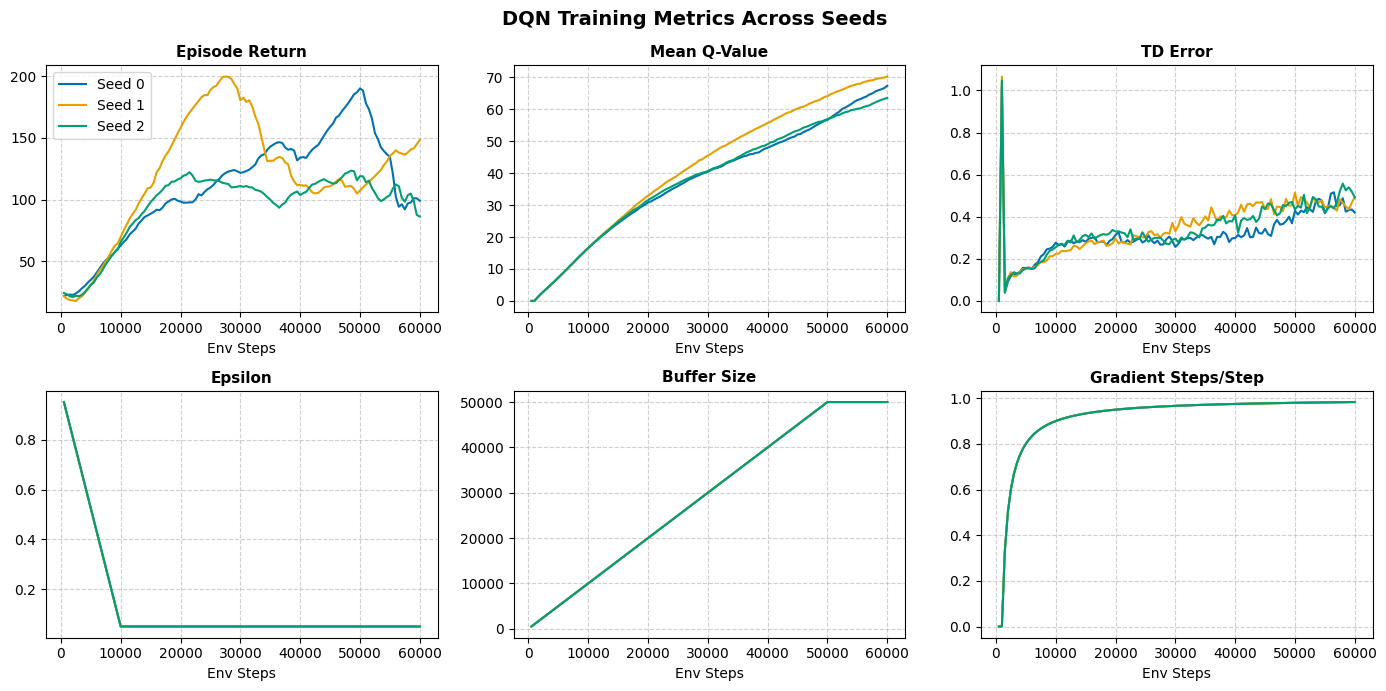

Average Inference Latency: 0.361 ms/action


In [34]:
colors = ["#0072B2", "#E69F00", "#009E73"]
metrics = ["return", "mean_q", "td_error", "epsilon", "buffer_size", "updates_per_step"]
titles = ["Episode Return", "Mean Q-Value", "TD Error", "Epsilon", "Buffer Size", "Gradient Steps/Step"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten() 

for i, metric in enumerate(metrics):
    ax = axes[i]
    for run_idx, res in enumerate(results):
        ax.plot(res["history"]["step"], res["history"][metric], 
                color=colors[run_idx % len(colors)], label=f"Seed {res['seed']}")

    ax.set_title(titles[i], fontsize=11, fontweight="bold")
    ax.set_xlabel("Env Steps")
    ax.grid(True, linestyle="--", alpha=0.6)

axes[0].legend(loc="upper left")
fig.suptitle("DQN Training Metrics Across Seeds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

final_latencies = [r["history"]["infer_ms"][-1] for r in results if r["history"]["infer_ms"]]
if final_latencies:
    print(f"Average Inference Latency: {np.mean(final_latencies):.3f} ms/action")